# Portfolio Risk Analyzer - Reliance & TCS
**Author:** Mahek
**Data:** NSE via yfinance | 2023-2024


In [6]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

reliance = yf.download('RELIANCE.NS', start ='2023-01-01', end = '2024-12-31')
tcs = yf.download('TCS.NS', start = '2023-01-01', end = '2024-12-31')

combined = pd.DataFrame({

    'RELIANCE' : reliance['Close'].squeeze(),
    'TCS' : tcs['Close'].squeeze()
})

returns = combined.pct_change() * 100
returns = returns.dropna()

print(returns.shape)
print(returns.describe())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


(489, 2)
         RELIANCE         TCS
count  489.000000  489.000000
mean     0.013350    0.068403
std      1.282511    1.240803
min     -7.485140   -4.219127
25%     -0.780037   -0.589525
50%      0.027434    0.004651
75%      0.725150    0.680151
max      7.019207    6.632790


In [7]:
weights = {'RELIANCE': 0.5, 'TCS': 0.5}

returns['Portfolio'] = (returns['RELIANCE'] * weights['RELIANCE'] + returns['TCS'] * weights['TCS'])
print(returns.head())
print(f"\n Portfolio Daily mean return: {returns['Portfolio'].mean():.3f}%")
print(f"\n Portfolio Daily volatilty: {returns['Portfolio'].std():.3f}%")

            RELIANCE       TCS  Portfolio
Date                                     
2023-01-03 -0.731785  1.530019   0.399117
2023-01-04 -1.505637  0.099643  -0.702997
2023-01-05 -0.178692 -0.107096  -0.142894
2023-01-06  0.908910 -3.006552  -1.048821
2023-01-09  2.361136  3.375309   2.868223

 Portfolio Daily mean return: 0.041%

 Portfolio Daily volatilty: 0.997%


In [9]:
print(f"Reliance volatility: {returns['RELIANCE'].std():.3f}%")
print(f"TCS volatility: {returns['TCS'].std():.3f}%")
print(f"Portfolio volatility: {returns['Portfolio'].std():.3f}%")

Reliance volatility: 1.283%
TCS volatility: 1.241%
Portfolio volatility: 0.997%


In [10]:
portfolio_value = 1000000
var_95 = returns['Portfolio']. quantile(0.05)
var_99 = returns['Portfolio']. quantile(0.01)
print(f"1 day VAR at 95% confidence: {var_95:.2f}% -> {abs(var_95/100 * portfolio_value):,.0f}")
print(f"1 day VAR at 99% confidence: {var_99:.2f}% -> {abs(var_99/100 * portfolio_value):,.0f}") 

1 day VAR at 95% confidence: -1.48% -> 14,766
1 day VAR at 99% confidence: -2.51% -> 25,096


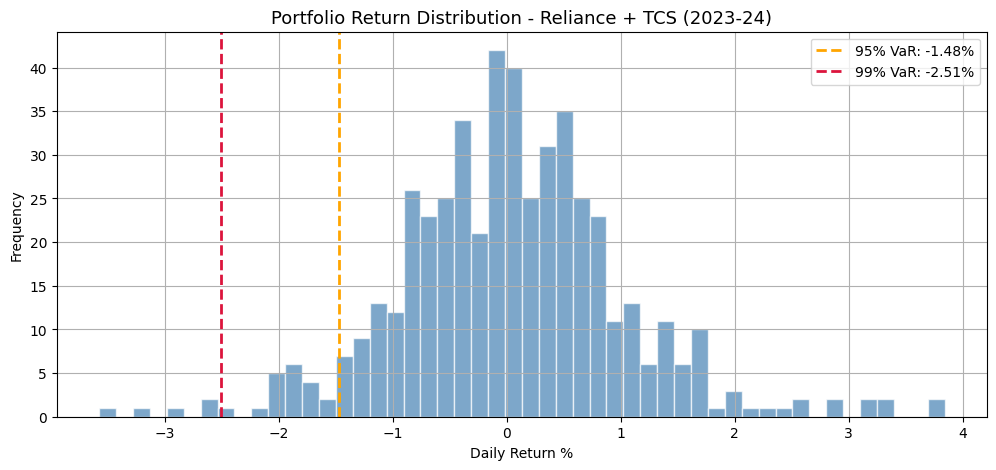

In [11]:
fig, ax = plt.subplots(figsize=(12,5))
returns['Portfolio'].hist(bins=50, ax=ax, color = 'steelblue', alpha=0.7, edgecolor ='white')
ax.axvline(var_95, color = 'orange', linewidth=2, linestyle = '--', label = f'95% VaR: {var_95:.2f}%')
ax.axvline(var_99, color = 'crimson', linewidth=2, linestyle = '--', label = f'99% VaR: {var_99:.2f}%')

ax.set_title('Portfolio Return Distribution - Reliance + TCS (2023-24)', fontsize = 13)
ax.set_xlabel('Daily Return %')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout
plt.show()